In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class DataSet:
    def __init__(self, num_samples):
        self.num_samples = num_samples
        self.x = torch.empty(self.num_samples, 1, 50)

    def create_samples(self):
        t = torch.linspace(0, 4*math.pi, 50)
        for i in range(self.num_samples):
            A = torch.randint(1, 50, (1,)).item()
            b = (torch.rand(1)*9.9 + 0.1).item()
            c = (torch.rand(1)* 10).item()
            wave = A * torch.sin(b*t + c)
            self.x[i] = wave

class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_embed = nn.Embedding(num_embeddings=1000, embedding_dim=64)
        self.down_conv = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.bottleneck_conv = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.up_sample = nn.Upsample(scale_factor=2, mode='nearest')
        self.up_conv = nn.Conv1d(in_channels=192, out_channels=64, kernel_size=3, padding=1)
        self.final_conv = nn.Conv1d(in_channels=64, out_channels=1, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        t_emb = t_emb.unsqueeze(-1)
        x1 = F.relu(self.down_conv(x))
        x1_time = x1 + t_emb
        x2 = self.pool(x1_time)
        x3 = F.relu(self.bottleneck_conv(x2))
        x4 = self.up_sample(x3)
        x_skip = torch.cat([x4, x1_time], dim=1)
        x5 = F.relu(self.up_conv(x_skip))
        predicted_noise = self.final_conv(x5)
        return predicted_noise

epochs = 500
data = DataSet(1000)
data.create_samples()
model = DiffusionModel()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
timesteps = 1000
beta = torch.linspace(0.0001, 0.02, timesteps)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)
tensor_data = TensorDataset(data.x)
dataloader = DataLoader(tensor_data, batch_size=128, shuffle=True)
for epoch in range(epochs):
    for batch in dataloader:
        x_0 = batch[0]
        batch_size = x_0.shape[0]
        t = torch.randint(0, timesteps, (batch_size,))
        true_noise = torch.randn_like(x_0)
        a_bar_t = alpha_bar[t]
        a_bar_t = a_bar_t.view(batch_size, 1, 1)
        x_t = torch.sqrt(a_bar_t) * x_0 + torch.sqrt(1 - a_bar_t) * true_noise
        optimizer.zero_grad()
        predicted_noise = model(x_t, t)
        loss = loss_fn(predicted_noise, true_noise)
        loss.backward()
        optimizer.step()



In [8]:
#DDIM vs DDPM

def ddim():
    timesteps = list(reversed(range(0, 1000, 100)))
    timesteps.append(0)
    with torch.no_grad():
        x = torch.randn(1, 1, 50)
        for i in range(len(timesteps) - 1):
            t = torch.tensor([timesteps[i]])
            t_prev = torch.tensor([timesteps[i + 1]])
            predicted_noise = model(x, t)
            a_bar_t = alpha_bar[t]
            a_bar_t_prev = alpha_bar[t_prev]
            pred_x0 = (x - torch.sqrt(1 - a_bar_t) * predicted_noise)/torch.sqrt(a_bar_t)
            pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)
            direction_pointing_to_xt = torch.sqrt(1 - a_bar_t_prev) * predicted_noise
            x = torch.sqrt(a_bar_t_prev) * pred_x0 + direction_pointing_to_xt
    return x

def ddpm():
    with torch.no_grad():
        x = torch.randn(1,1,50)
        for i in reversed(range(1000)):
            t = torch.tensor([i])
            predicted_noise=model(x, t)
            alpha_t = alpha[t]
            alpha_bar_t = alpha_bar[t]
            beta_t = beta[t]
            x = (1 / torch.sqrt(alpha_t)) * (x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise)
            if i>0:
                noise = torch.randn_like(x)
                x = x+torch.sqrt(beta_t)*noise
    return x


Generating 10 separate waves...


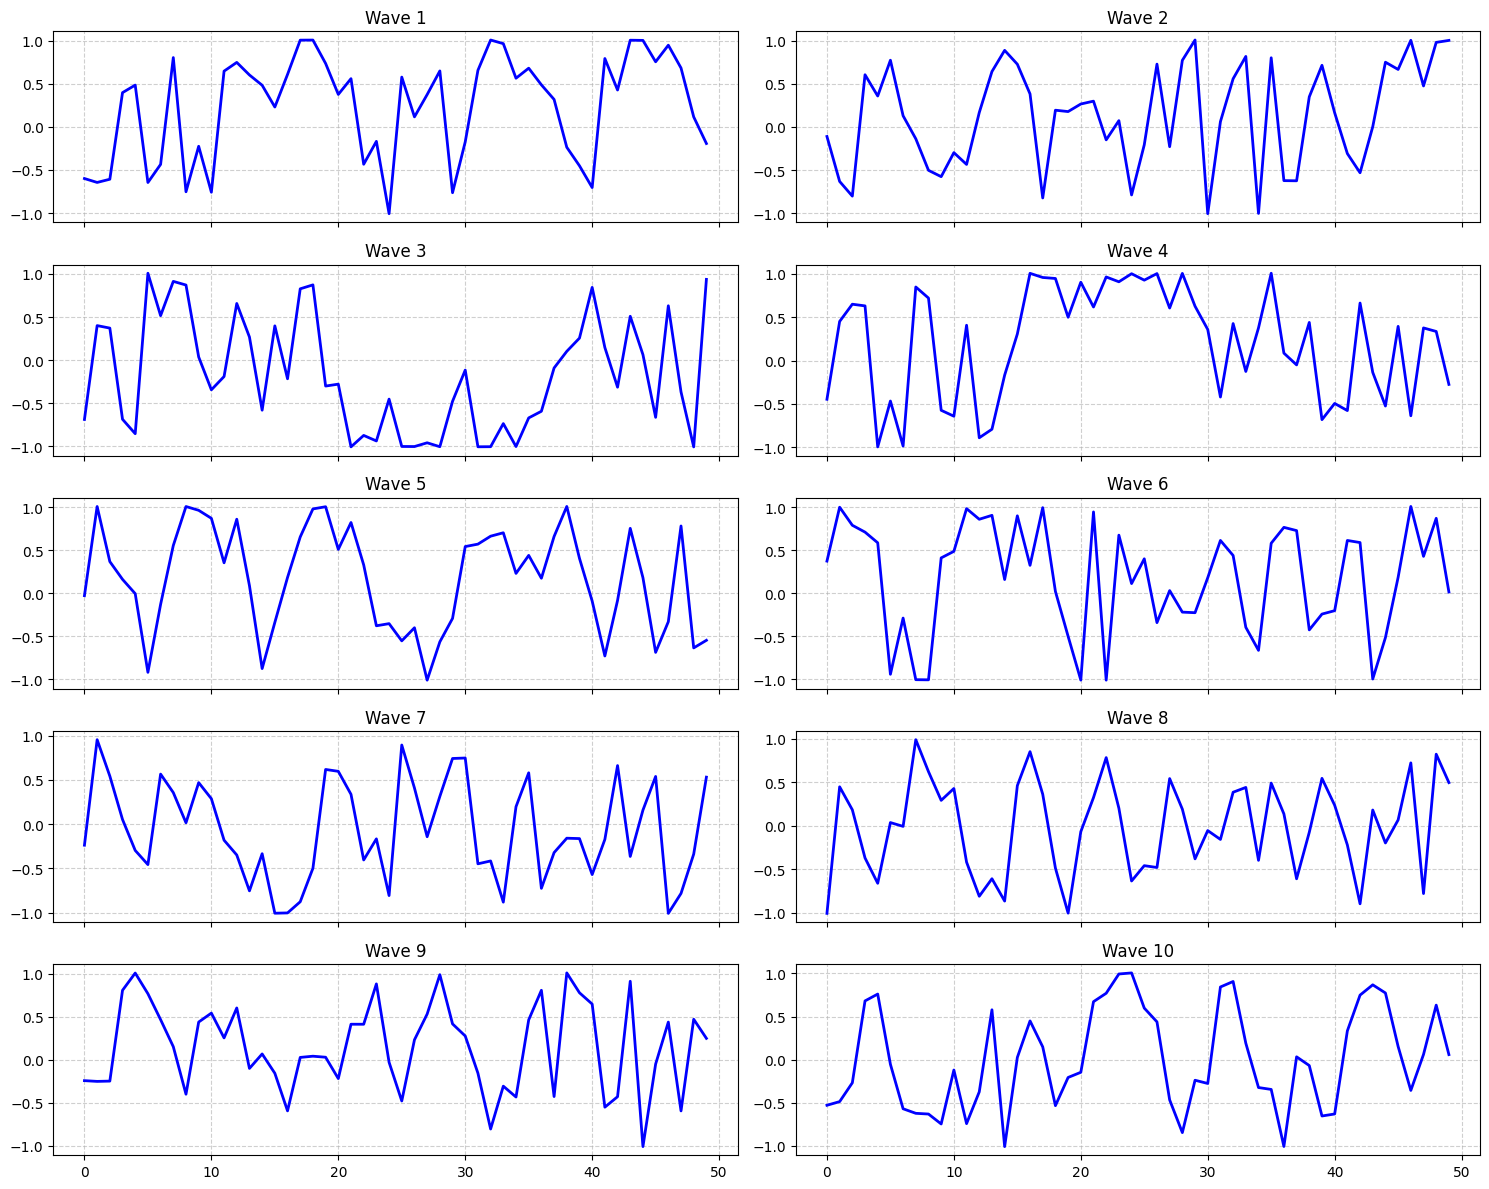

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 12))
axes = axes.flatten()
for i in range(10):
    wave = ddim().squeeze().numpy()
    axes[i].plot(wave, color="blue", linewidth=2)
    axes[i].set_title(f"Wave {i+1}")
    axes[i].grid(True, linestyle="--", alpha=0.6)
    if i < 8:
        axes[i].set_xticklabels([])
plt.tight_layout()
plt.show()


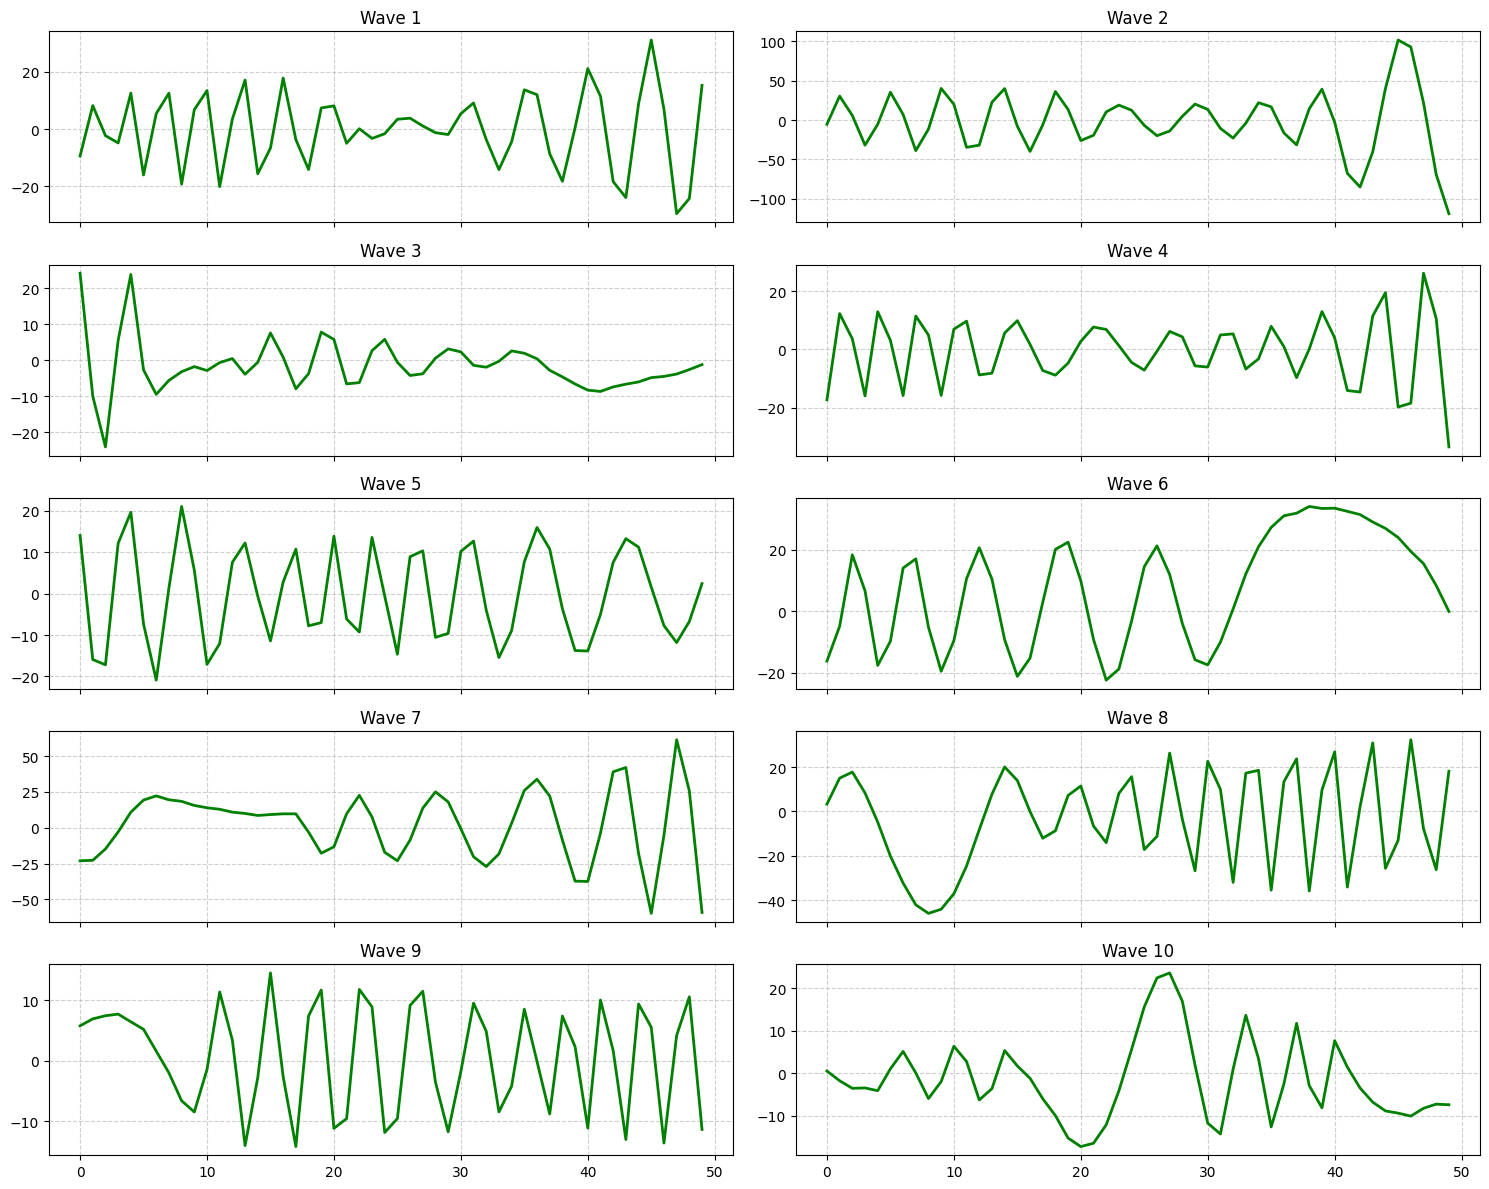

In [11]:
fig, axes = plt.subplots(nrows = 5, ncols=2, figsize=(15, 12))
axes = axes.flatten()
for i in range(10):
    wave = ddpm().squeeze().numpy()
    axes[i].plot(wave, color = 'green', linewidth = 2)
    axes[i].set_title(f"Wave {i+1}")
    axes[i].grid(True, linestyle="--", alpha=0.6)
    if i < 8:
        axes[i].set_xticklabels([])
plt.tight_layout()
plt.show()